In [5]:

import sys
sys.path.append('../')
from simulation.core import SimulationParams, simulate_Y, simulate_MM_quotes
import numpy as np
import matplotlib.pyplot as plt

In [6]:
%load_ext autoreload
%autoreload 2
params = SimulationParams()
times, prices = simulate_Y(params)
quote_times, bids, asks = simulate_MM_quotes(params, times, prices)
midpoints = (bids + asks) / 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


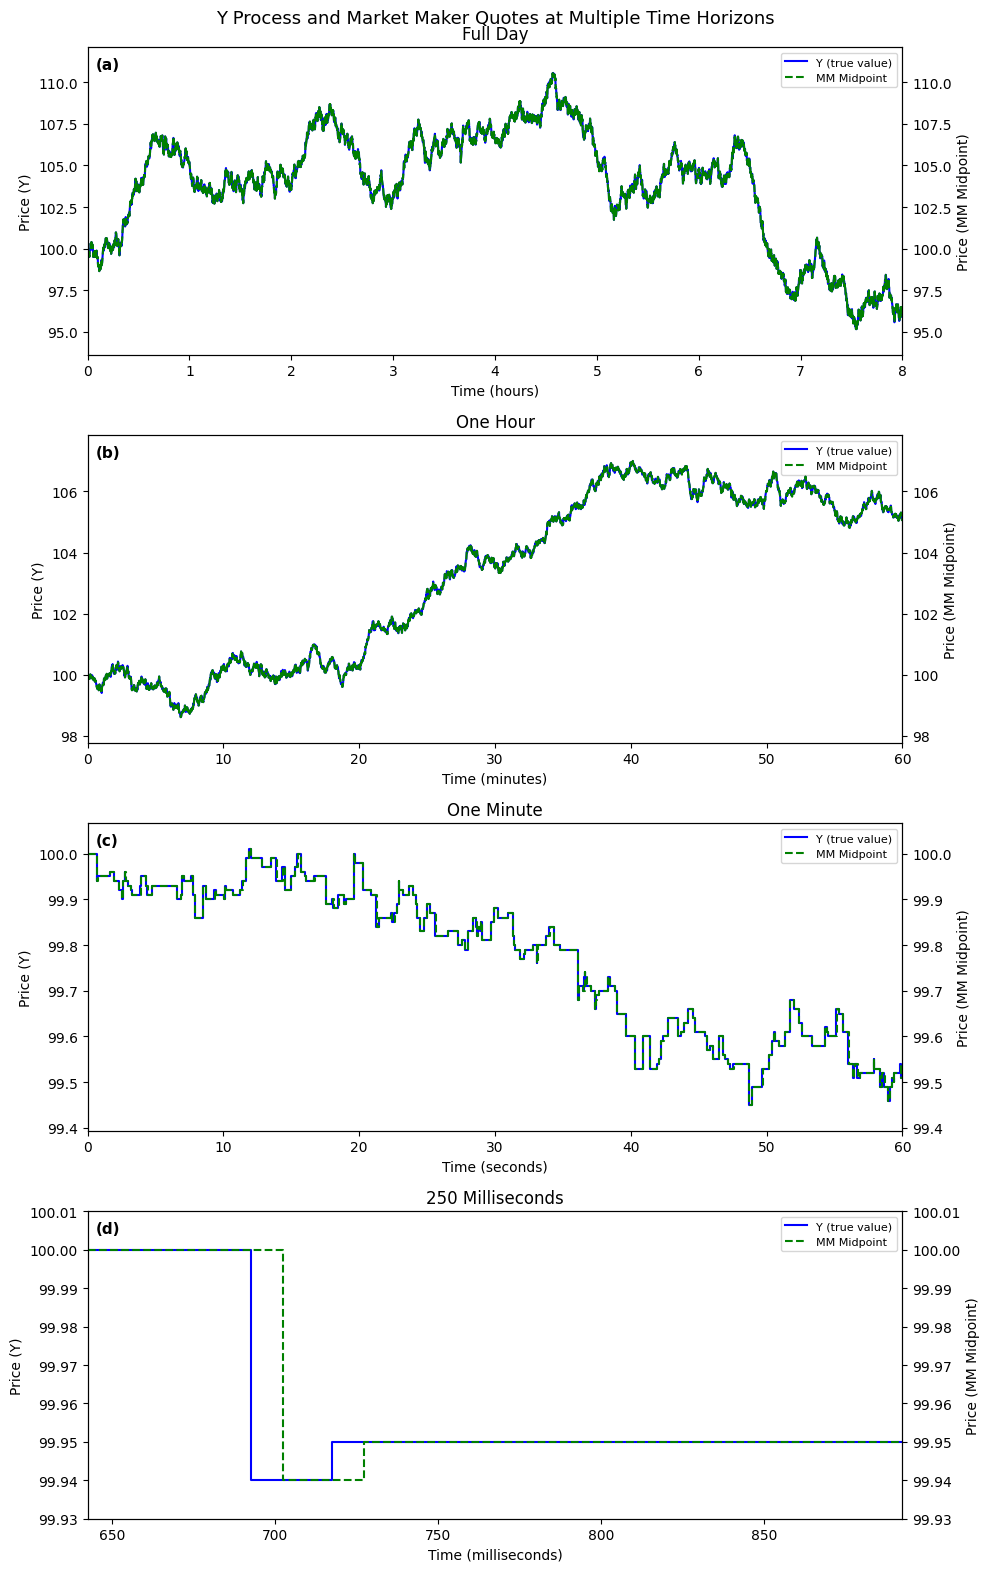

In [7]:
def resample_for_plot(t_arr, v_arr, interval_seconds, t_start, t_end):
    """Resample sparse event series to a fixed time grid via forward-fill."""
    grid = np.arange(t_start, t_end + interval_seconds, interval_seconds)
    grid = grid[grid <= t_end]
    indices = np.searchsorted(t_arr, grid, side='right') - 1
    indices = np.clip(indices, 0, len(v_arr) - 1)
    return grid, v_arr[indices]

def window_data(t_arr, v_arr, t_start, t_end, fallback):
    """Slice sparse event series to [t_start, t_end], anchoring both edges."""
    before = t_arr <= t_start
    v_left = v_arr[before][-1] if before.any() else fallback
    inside = (t_arr > t_start) & (t_arr <= t_end)
    v_right = v_arr[inside][-1] if inside.any() else v_left
    t_plot = np.concatenate([[t_start], t_arr[inside], [t_end]])
    v_plot = np.concatenate([[v_left],  v_arr[inside], [v_right]])
    return t_plot, v_plot

first_jump = times[1]
c_start = max(0.0, first_jump - 10.0)
d_start = max(0.0, first_jump - 0.050)

# (label, title, t_start, t_end, resample_s, t_scale, t_unit)
panels = [
    ('(a)', 'Full Day',         0.0,     params.T,         5.0,  1/3600, 'hours'),
    ('(b)', 'One Hour',         0.0,     3600.0,           1.0,  1/60,   'minutes'),
    ('(c)', 'One Minute',       c_start, c_start + 60.0,  None, 1.0,    'seconds'),
    ('(d)', '250 Milliseconds', d_start, d_start + 0.25,  None, 1000.0, 'milliseconds'),
]

fig, axes = plt.subplots(4, 1, figsize=(10, 16))
fig.suptitle('Y Process and Market Maker Quotes at Multiple Time Horizons', fontsize=13)

for ax, (label, title, t_start, t_end, resample_s, t_scale, t_unit) in zip(axes, panels):
    if resample_s is not None:
        t_y,  p_y  = resample_for_plot(times,       prices,    resample_s, t_start, t_end)
        t_mm, m_mm = resample_for_plot(quote_times, midpoints, resample_s, t_start, t_end)
        draw = 'default'
    else:
        t_y,  p_y  = window_data(times,       prices,    t_start, t_end, params.Y0)
        t_mm, m_mm = window_data(quote_times, midpoints, t_start, t_end, midpoints[0])
        draw = 'steps-post'

    ax2 = ax.twinx()
    ax.plot( t_y  * t_scale, p_y,  color='blue',  linestyle='-',  drawstyle=draw, label='Y (true value)')
    ax2.plot(t_mm * t_scale, m_mm, color='green', linestyle='--', drawstyle=draw, label='MM Midpoint')

    ax.set_ylabel('Price (Y)')
    ax2.set_ylabel('Price (MM Midpoint)')
    ax.set_xlabel(f'Time ({t_unit})')
    ax.set_xlim(t_start * t_scale, t_end * t_scale)
    ax.set_title(title)

    y_min = min(p_y.min(), m_mm.min())
    y_max = max(p_y.max(), m_mm.max())
    pad = max((y_max - y_min) * 0.1, params.tick_size)
    ax.set_ylim(y_min - pad, y_max + pad)
    ax2.set_ylim(y_min - pad, y_max + pad)

    ax.yaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter(useOffset=False))
    ax2.yaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter(useOffset=False))

    ax.text(0.01, 0.97, label, transform=ax.transAxes, fontsize=11, fontweight='bold', va='top')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

In [9]:
total_jumps = len(times) - 1  # exclude t=0 entry
avg_jumps_per_hour = total_jumps / params.trading_hours
y_min_price = prices.min()
y_max_price = prices.max()
mm_lag_ms = params.mm_lag * 1000

print(f"Total jumps:            {total_jumps}")
print(f"Average jumps per hour: {avg_jumps_per_hour:.1f}")
print(f"Y price range:          {y_min_price:.2f} to {y_max_price:.2f}")
print(f"MM lag:                 {mm_lag_ms:.0f}ms")
print(f"Simulation seed:        {params.seed}")

Total jumps:            99937
Average jumps per hour: 12492.1
Y price range:          95.07 to 110.64
MM lag:                 10ms
Simulation seed:        42
